In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt

from process_and_save_recording import load_recording, combine_accel_gyro, add_annotations_to_combined, add_predictions_to_combined

# Load recording

In [2]:
path = "session_1776938763711"
accel, gyro, classification, annotations, info = load_recording(path)
accel.shape, gyro.shape, classification.shape, annotations.keys(), len(annotations["events"]), info

((173106, 4),
 (173106, 4),
 (3448, 6),
 dict_keys(['phoneStartTimestamp', 'phoneEndTimestamp', 'events']),
 17,
 ['start_time=1776938764551',
  'phone_timestamp=1776938763711',
  'end_time=1776942234017'])

In [3]:
accel

,timestamp,x,y,z
0,591649351543695,0.883460,-1.783680,9.488221
1,591649371652618,0.995988,-1.898602,9.380483
2,591649391724580,1.010353,-2.114080,9.232041
3,591649413884080,0.998382,-1.975216,9.502586
4,591649431993426,1.024718,-1.764527,9.366117
...,...,...,...,...
173101,595118706549386,-0.557849,-10.146626,-3.311181
173102,595118726587540,0.835576,-8.257602,-3.076549
173103,595118746625309,1.398214,-9.270349,-3.653552
173104,595118766662270,-0.940921,-10.019734,-4.903325


In [4]:
gyro

,timestamp,x,y,z
0,591649351546272,-0.019548,0.084299,-0.072082
1,591649371654926,-0.064752,0.075747,-0.080634
2,591649391727157,-0.029322,0.059865,-0.067195
3,591649413886426,0.048869,0.050091,-0.059865
4,591649431996003,0.043982,0.036652,-0.076969
...,...,...,...,...
173101,595118706551809,0.210138,0.166155,0.069639
173102,595118726589732,0.125838,0.089186,0.125838
173103,595118746627732,-0.384845,0.109956,-0.095295
173104,595118766664463,-0.348193,0.400728,0.034208


In [5]:
classification

,timestamp,prediction_float,prediction_binary,accel_timestamps,gyro_timestamps,window_data
0,1776938764605,0.524715,1,591647365035472;591647385036049;59164740511912...,591647365037780;591647385038587;59164740512143...,0.1388637|-1.7621324|9.895236|0.008552114|-0.1...
1,1776938765621,0.224435,0,591648387537430;591648407548237;59164842764254...,591648387539968;591648407550583;59164842764512...,0.94331545|-1.7022774|9.52174|0.017104227|0.02...
2,1776938766627,0.011682,0,591649413884080;591649431993426;59164945209177...,591649413886426;591649431996003;59164945209411...,0.9983821|-1.9752164|9.502586|0.04886922|0.050...
3,1776938767642,0.025886,0,591650415305306;591650435338576;59165045542419...,591650415307614;591650435341153;59165045542653...,0.8523358|-2.2457612|9.543288|0.07452556|-0.01...
4,1776938768629,0.008792,0,591651418218880;591651438270956;59165145831941...,591651418221226;591651438273533;59165145832172...,1.2545617|-2.2457612|9.471462|0.009773844|-0.0...
...,...,...,...,...,...,...
3443,1776942229346,0.009142,0,595112133545449;595112153590949;59511217362860...,595112133547872;595112153593142;59511217363106...,2.1883004|-4.3837833|-7.680599|0.23579398|-0.6...
3444,1776942230353,0.044772,0,595113135316946;595113155352099;59511317538240...,595113135319369;595113155354292;59511317538486...,2.8538885|-8.6574335|-6.64391|0.30665436|-0.24...
3445,1776942231361,0.099559,0,595114137366634;595114157408826;59511417745744...,595114137369057;595114157411019;59511417745986...,0.93134445|-8.832211|-0.2873042|0.9615019|0.03...
3446,1776942232365,0.030771,0,595115159167746;595115179205515;59511519924039...,595115159169899;595115179207938;59511519924259...,3.323152|-8.7053175|-4.3263226|0.02443461|0.17...


In [6]:
annotations

{'phoneStartTimestamp': 1776938763711,
 'phoneEndTimestamp': 1776942233676,
 'events': [{'name': 'Cable Rows',
   'startTime': 1776942047122,
   'endTime': 1776942080790},
  {'name': 'Cable Rows', 'startTime': 1776941847606, 'endTime': 1776941888501},
  {'name': 'Ab Crunche Machine',
   'startTime': 1776941585577,
   'endTime': 1776941617845},
  {'name': 'Ab Crunche Machine',
   'startTime': 1776941435698,
   'endTime': 1776941477093},
  {'name': 'Chest Fly Machine',
   'startTime': 1776941243339,
   'endTime': 1776941289030},
  {'name': 'Chest Fly Machine',
   'startTime': 1776941042807,
   'endTime': 1776941102328},
  {'name': 'Tricep Pushdowns',
   'startTime': 1776940830952,
   'endTime': 1776940859413},
  {'name': 'Tricep Pushdowns',
   'startTime': 1776940690247,
   'endTime': 1776940736328},
  {'name': 'Dumbbell Overhead Press',
   'startTime': 1776940485170,
   'endTime': 1776940528863},
  {'name': 'Dumbbell Overhead Press',
   'startTime': 1776940331688,
   'endTime': 17769403

In [7]:
info

['start_time=1776938764551',
 'phone_timestamp=1776938763711',
 'end_time=1776942234017']

# Sanity check recording

## Start and end timestamps

In [8]:
def print_recording_stats(accel, gyro, classification, annotations, info):
    phone_start_timestamp = annotations["phoneStartTimestamp"]
    phone_end_timestamp = annotations["phoneEndTimestamp"]
    watch_start_timestamp = int(info[0].split('=')[1])
    watch_end_timestamp = int(info[2].split('=')[1])
    print(f"Phone start timestamp:\t {phone_start_timestamp}\t ({pd.to_datetime(phone_start_timestamp, unit='ms')})")
    print(f"Phone end timestamp:\t {phone_end_timestamp}\t ({pd.to_datetime(phone_end_timestamp, unit='ms')})")
    print("Duration of phone recording:", pd.to_timedelta(phone_end_timestamp - phone_start_timestamp, unit='ms'))
    print(f"Watch start timestamp:\t {watch_start_timestamp}\t ({pd.to_datetime(watch_start_timestamp, unit='ms')})")
    print(f"Watch end timestamp:\t {watch_end_timestamp}\t ({pd.to_datetime(watch_end_timestamp, unit='ms')})")
    print("Duration of watch recording:", pd.to_timedelta(watch_end_timestamp - watch_start_timestamp, unit='ms'))
    print("Duration difference between phone and watch recordings (ms):", (phone_end_timestamp - phone_start_timestamp) - (watch_end_timestamp - watch_start_timestamp))
    print("Difference between phone and watch start timestamps (ms):", phone_start_timestamp - watch_start_timestamp)
    print("Difference between phone and watch end timestamps (ms):", phone_end_timestamp - watch_end_timestamp)

In [9]:
print_recording_stats(accel, gyro, classification, annotations, info)

Phone start timestamp:	 1776938763711	 (2026-04-23 10:06:03.711000)
Phone end timestamp:	 1776942233676	 (2026-04-23 11:03:53.676000)
Duration of phone recording: 0 days 00:57:49.965000
Watch start timestamp:	 1776938764551	 (2026-04-23 10:06:04.551000)
Watch end timestamp:	 1776942234017	 (2026-04-23 11:03:54.017000)
Duration of watch recording: 0 days 00:57:49.466000
Duration difference between phone and watch recordings (ms): 499
Difference between phone and watch start timestamps (ms): -840
Difference between phone and watch end timestamps (ms): -341


In [10]:
def print_recording_imu_stats(accel, gyro):
    # accel, gyro timestamps are in nanoseconds
    print(f"First accel timestamp:\t {accel['timestamp'][0]}\t ({pd.to_datetime(accel['timestamp'][0], unit='ns')})")
    print(f"First gyro timestamp:\t {gyro['timestamp'][0]}\t ({pd.to_datetime(gyro['timestamp'][0], unit='ns')})")
    print("Duration of accel recording:", pd.to_timedelta(accel['timestamp'].iloc[-1] - accel['timestamp'][0], unit='ns'))
    print(f"Last accel timestamp:\t {accel['timestamp'].iloc[-1]}\t ({pd.to_datetime(accel['timestamp'].iloc[-1], unit='ns')})")
    print(f"Last gyro timestamp:\t {gyro['timestamp'].iloc[-1]}\t ({pd.to_datetime(gyro['timestamp'].iloc[-1], unit='ns')})")
    print("Duration of gyro recording:", pd.to_timedelta(gyro['timestamp'].iloc[-1] - gyro['timestamp'][0], unit='ns'))
    print("Duration difference between accel and gyro recordings (ns):", (accel['timestamp'].iloc[-1] - accel['timestamp'][0]) - (gyro['timestamp'].iloc[-1] - gyro['timestamp'][0]))
    print("Difference between accel and gyro start timestamps (ns):", accel['timestamp'][0] - gyro['timestamp'][0])
    print("Difference between accel and gyro end timestamps (ns):", accel['timestamp'].iloc[-1] - gyro['timestamp'].iloc[-1])

In [11]:
print_recording_imu_stats(accel, gyro)

First accel timestamp:	 591649351543695	 (1970-01-07 20:20:49.351543695)
First gyro timestamp:	 591649351546272	 (1970-01-07 20:20:49.351546272)
Duration of accel recording: 0 days 00:57:49.435164575
Last accel timestamp:	 595118786708270	 (1970-01-07 21:18:38.786708270)
Last gyro timestamp:	 595118786710693	 (1970-01-07 21:18:38.786710693)
Duration of gyro recording: 0 days 00:57:49.435164421
Duration difference between accel and gyro recordings (ns): 154
Difference between accel and gyro start timestamps (ns): -2577
Difference between accel and gyro end timestamps (ns): -2423


## Sorted? Duplicates?

In [12]:
# is accel and gyro sorted?
print("Is accel sorted by timestamp?", accel['timestamp'].is_monotonic_increasing)
print("Is gyro sorted by timestamp?", gyro['timestamp'].is_monotonic_increasing)

Is accel sorted by timestamp? True
Is gyro sorted by timestamp? True


In [13]:
# detect duplicates
accel_duplicates = accel[accel.duplicated(subset='timestamp', keep=False)]
gyro_duplicates = gyro[gyro.duplicated(subset='timestamp', keep=False)]
print(f"Number of duplicate timestamps in accel: {len(accel_duplicates)}")
print(f"Number of duplicate timestamps in gyro: {len(gyro_duplicates)}")

Number of duplicate timestamps in accel: 0
Number of duplicate timestamps in gyro: 0


## Differences in rows and sequential rows

In [14]:
# Compare timestamps row by row
def compare_timestamps(accel, gyro, threshold_ms=1):
    for idx in range(len(accel)):
        accel_ts = accel.iloc[idx]['timestamp']
        gyro_ts = gyro.iloc[idx]['timestamp']
        diff = accel_ts - gyro_ts
        if abs(diff) > threshold_ms * 1_000_000:  # Convert ms to nanoseconds
            print(f"Row {idx}: accel={accel_ts}, gyro={gyro_ts}, diff={(diff) / 1_000_000:.2f}ms")

In [15]:
# Are accel and gyro timestamps aligned?
compare_timestamps(accel, gyro, threshold_ms=1)

In [16]:
# Sequential differences between consecutive rows
def print_sequential_differences(accel, gyro, threshold_ms=22):
    print(f"Sequential timestamp differences (>={threshold_ms}ms):")
    for idx in range(len(accel) - 1):
        accel_curr = accel.iloc[idx]['timestamp']
        accel_next = accel.iloc[idx + 1]['timestamp']
        accel_seq_diff_ms = (accel_next - accel_curr) / 1_000_000  # Convert ns to ms
    
    gyro_curr = gyro.iloc[idx]['timestamp']
    gyro_next = gyro.iloc[idx + 1]['timestamp']
    gyro_seq_diff_ms = (gyro_next - gyro_curr) / 1_000_000  # Convert ns to ms
    
    if accel_seq_diff_ms > threshold_ms or gyro_seq_diff_ms > threshold_ms:
        print(f"Row {idx}->{idx+1}: accel_diff={accel_seq_diff_ms:.2f}ms, gyro_diff={gyro_seq_diff_ms:.2f}ms")
        # # print out few rows timestamps and time diff around the gap for context
        # accels = accel.iloc[max(0, idx-5):min(len(accel), idx+5)][['timestamp']]
        # gyros = gyro.iloc[max(0, idx-5):min(len(gyro), idx+5)][['timestamp']]
        # print("Accel timestamps around gap:")
        # for i, row in accels.iterrows():
        #     print(f"Row {i}: {row['timestamp']} ({(row['timestamp'] - accel_curr) / 1_000_000:.2f}ms from current)")
        # print("Gyro timestamps around gap:")
        # for i, row in gyros.iterrows():
        #     print(f"Row {i}: {row['timestamp']} ({(row['timestamp'] - gyro_curr) / 1_000_000:.2f}ms from current)")

In [17]:
print_sequential_differences(accel, gyro, threshold_ms=21)

Sequential timestamp differences (>=21ms):


## Difference statistics

In [18]:
# Calculate statistics for differences
def calculate_accel_gyro_differences(accel, gyro):
    accel_gyro_diffs_ms = []
    for idx in range(len(accel)):
        accel_ts = accel.iloc[idx]['timestamp']
        gyro_ts = gyro.iloc[idx]['timestamp']
        diff_ms = abs(accel_ts - gyro_ts) / 1_000_000
        accel_gyro_diffs_ms.append(diff_ms)
    return accel_gyro_diffs_ms

def calculate_sequential_differences(accel, gyro):
    accel_seq_diffs_ms = []
    gyro_seq_diffs_ms = []
    for idx in range(len(accel) - 1):
        accel_seq_diff = (accel.iloc[idx + 1]['timestamp'] - accel.iloc[idx]['timestamp']) / 1_000_000
        gyro_seq_diff = (gyro.iloc[idx + 1]['timestamp'] - gyro.iloc[idx]['timestamp']) / 1_000_000
        accel_seq_diffs_ms.append(accel_seq_diff)
        gyro_seq_diffs_ms.append(gyro_seq_diff)
    return accel_seq_diffs_ms, gyro_seq_diffs_ms

def print_difference_stats(accel_gyro_diffs_ms, accel_seq_diffs_ms, gyro_seq_diffs_ms):
    print("=" * 60)
    print("ACCEL-GYRO SYNC DIFFERENCES (ms)")
    print("=" * 60)
    print(f"Mean: {np.mean(accel_gyro_diffs_ms):.4f}ms")
    print(f"Std Dev: {np.std(accel_gyro_diffs_ms):.4f}ms")
    print(f"Min: {np.min(accel_gyro_diffs_ms):.4f}ms")
    print(f"Max: {np.max(accel_gyro_diffs_ms):.4f}ms")
    print(f"Median: {np.median(accel_gyro_diffs_ms):.4f}ms")
    print(f"Q1 (25%): {np.percentile(accel_gyro_diffs_ms, 25):.4f}ms")
    print(f"Q3 (75%): {np.percentile(accel_gyro_diffs_ms, 75):.4f}ms")

    print("\n" + "=" * 60)
    print("ACCEL SEQUENTIAL DIFFERENCES (ms)")
    print("=" * 60)
    print(f"Mean: {np.mean(accel_seq_diffs_ms):.4f}ms")
    print(f"Std Dev: {np.std(accel_seq_diffs_ms):.4f}ms")
    print(f"Min: {np.min(accel_seq_diffs_ms):.4f}ms")
    print(f"Max: {np.max(accel_seq_diffs_ms):.4f}ms")
    print(f"Median: {np.median(accel_seq_diffs_ms):.4f}ms")
    print(f"Q1 (25%): {np.percentile(accel_seq_diffs_ms, 25):.4f}ms")
    print(f"Q3 (75%): {np.percentile(accel_seq_diffs_ms, 75):.4f}ms")

    print("\n" + "=" * 60)
    print("GYRO SEQUENTIAL DIFFERENCES (ms)")
    print("=" * 60)
    print(f"Mean: {np.mean(gyro_seq_diffs_ms):.4f}ms")
    print(f"Std Dev: {np.std(gyro_seq_diffs_ms):.4f}ms")
    print(f"Min: {np.min(gyro_seq_diffs_ms):.4f}ms")
    print(f"Max: {np.max(gyro_seq_diffs_ms):.4f}ms")
    print(f"Median: {np.median(gyro_seq_diffs_ms):.4f}ms")
    print(f"Q1 (25%): {np.percentile(gyro_seq_diffs_ms, 25):.4f}ms")
    print(f"Q3 (75%): {np.percentile(gyro_seq_diffs_ms, 75):.4f}ms")

def calculate_and_print_difference_stats(accel, gyro):
# Accel-Gyro timestamp differences (sync differences)
    accel_gyro_diffs_ms = calculate_accel_gyro_differences(accel, gyro)
    accel_seq_diffs_ms, gyro_seq_diffs_ms = calculate_sequential_differences(accel, gyro)
    print_difference_stats(accel_gyro_diffs_ms, accel_seq_diffs_ms, gyro_seq_diffs_ms)

In [19]:
calculate_and_print_difference_stats(accel, gyro)

ACCEL-GYRO SYNC DIFFERENCES (ms)
Mean: 0.0023ms
Std Dev: 0.0001ms
Min: 0.0022ms
Max: 0.0043ms
Median: 0.0023ms
Q1 (25%): 0.0022ms
Q3 (75%): 0.0024ms

ACCEL SEQUENTIAL DIFFERENCES (ms)
Mean: 20.0424ms
Std Dev: 0.1368ms
Min: 17.7023ms
Max: 22.1595ms
Median: 20.0282ms
Q1 (25%): 20.0153ms
Q3 (75%): 20.0614ms

GYRO SEQUENTIAL DIFFERENCES (ms)
Mean: 20.0424ms
Std Dev: 0.1368ms
Min: 17.7026ms
Max: 22.1593ms
Median: 20.0282ms
Q1 (25%): 20.0153ms
Q3 (75%): 20.0615ms


## Classifications

In [20]:
classification

,timestamp,prediction_float,prediction_binary,accel_timestamps,gyro_timestamps,window_data
0,1776938764605,0.524715,1,591647365035472;591647385036049;59164740511912...,591647365037780;591647385038587;59164740512143...,0.1388637|-1.7621324|9.895236|0.008552114|-0.1...
1,1776938765621,0.224435,0,591648387537430;591648407548237;59164842764254...,591648387539968;591648407550583;59164842764512...,0.94331545|-1.7022774|9.52174|0.017104227|0.02...
2,1776938766627,0.011682,0,591649413884080;591649431993426;59164945209177...,591649413886426;591649431996003;59164945209411...,0.9983821|-1.9752164|9.502586|0.04886922|0.050...
3,1776938767642,0.025886,0,591650415305306;591650435338576;59165045542419...,591650415307614;591650435341153;59165045542653...,0.8523358|-2.2457612|9.543288|0.07452556|-0.01...
4,1776938768629,0.008792,0,591651418218880;591651438270956;59165145831941...,591651418221226;591651438273533;59165145832172...,1.2545617|-2.2457612|9.471462|0.009773844|-0.0...
...,...,...,...,...,...,...
3443,1776942229346,0.009142,0,595112133545449;595112153590949;59511217362860...,595112133547872;595112153593142;59511217363106...,2.1883004|-4.3837833|-7.680599|0.23579398|-0.6...
3444,1776942230353,0.044772,0,595113135316946;595113155352099;59511317538240...,595113135319369;595113155354292;59511317538486...,2.8538885|-8.6574335|-6.64391|0.30665436|-0.24...
3445,1776942231361,0.099559,0,595114137366634;595114157408826;59511417745744...,595114137369057;595114157411019;59511417745986...,0.93134445|-8.832211|-0.2873042|0.9615019|0.03...
3446,1776942232365,0.030771,0,595115159167746;595115179205515;59511519924039...,595115159169899;595115179207938;59511519924259...,3.323152|-8.7053175|-4.3263226|0.02443461|0.17...


In [21]:
# Are timestamps in windows sorted? duplicates?
def check_classification_windows(classification):
    all_is_sorted = True
    all_no_duplicates = True
    for idx, row in classification.iterrows():
        accel_timestamps = [int(ts) for ts in row['accel_timestamps'].split(';')]
        gyro_timestamps = [int(ts) for ts in row['gyro_timestamps'].split(';')]

        # Check if accel timestamps are sorted
        accel_is_sorted = all(earlier <= later for earlier, later in zip(accel_timestamps, accel_timestamps[1:]))
        if not accel_is_sorted:
            all_is_sorted = False
            print(f"Row {idx}: accel timestamps are not sorted")

        gyro_is_sorted = all(earlier <= later for earlier, later in zip(gyro_timestamps, gyro_timestamps[1:]))
        if not gyro_is_sorted:
            all_is_sorted = False
            print(f"Row {idx}: gyro timestamps are not sorted")
        
        # Check for duplicates in accel timestamps
        accel_duplicates = pd.Series(accel_timestamps).duplicated(keep=False)
        if accel_duplicates.any():
            all_no_duplicates = False
            print(f"Row {idx}: accel timestamps have duplicates")

        gyro_duplicates = pd.Series(gyro_timestamps).duplicated(keep=False)
        if gyro_duplicates.any():
            all_no_duplicates = False
            print(f"Row {idx}: gyro timestamps have duplicates")

    if all_is_sorted:
        print("All windows have sorted timestamps.")
    else:
        print("Some windows have unsorted timestamps.")

    if all_no_duplicates:
        print("All windows have unique timestamps.")
    else:
        print("Some windows have duplicate timestamps.")

In [22]:
check_classification_windows(classification)

All windows have sorted timestamps.
All windows have unique timestamps.


In [23]:
# Check timestamp differences between windows
def check_differences_between_windows(classification):
    gaps = []
    # check how much times is inbetween end of accel timestamps of one window and start of accel timestamps of next window, same for gyro
    for idx in range(len(classification) - 1):
        current_row = classification.iloc[idx]
        next_row = classification.iloc[idx + 1]

        current_accel_end = int(current_row['accel_timestamps'].split(';')[-1])
        next_accel_start = int(next_row['accel_timestamps'].split(';')[0])
        accel_diff_ms = (next_accel_start - current_accel_end) / 1_000_000

        current_gyro_end = int(current_row['gyro_timestamps'].split(';')[-1])
        next_gyro_start = int(next_row['gyro_timestamps'].split(';')[0])
        gyro_diff_ms = (next_gyro_start - current_gyro_end) / 1_000_000

        gaps.append((idx, accel_diff_ms, gyro_diff_ms))

    # statistics about gaps
    accel_gaps_ms = [gap[1] for gap in gaps]
    gyro_gaps_ms = [gap[2] for gap in gaps]
    print("Accel window gaps (ms):")
    print(f"Mean: {np.mean(accel_gaps_ms):.4f}ms")
    print(f"Std Dev: {np.std(accel_gaps_ms):.4f}ms")
    print(f"Min: {np.min(accel_gaps_ms):.4f}ms")
    print(f"Max: {np.max(accel_gaps_ms):.4f}ms")
    print(f"Median: {np.median(accel_gaps_ms):.4f}ms")
    print(f"Q1 (25%): {np.percentile(accel_gaps_ms, 25):.4f}ms")
    print(f"Q3 (75%): {np.percentile(accel_gaps_ms, 75):.4f}ms")
    print("\nGyro window gaps (ms):")
    print(f"Mean: {np.mean(gyro_gaps_ms):.4f}ms")
    print(f"Std Dev: {np.std(gyro_gaps_ms):.4f}ms")
    print(f"Min: {np.min(gyro_gaps_ms):.4f}ms")
    print(f"Max: {np.max(gyro_gaps_ms):.4f}ms")
    print(f"Median: {np.median(gyro_gaps_ms):.4f}ms")
    print(f"Q1 (25%): {np.percentile(gyro_gaps_ms, 25):.4f}ms")
    print(f"Q3 (75%): {np.percentile(gyro_gaps_ms, 75):.4f}ms")


In [24]:
check_differences_between_windows(classification)

Accel window gaps (ms):
Mean: -977.8743ms
Std Dev: 8.6774ms
Min: -1021.1010ms
Max: -941.1311ms
Median: -981.1785ms
Q1 (25%): -982.3352ms
Q3 (75%): -980.8067ms

Gyro window gaps (ms):
Mean: -977.8743ms
Std Dev: 8.6774ms
Min: -1021.1007ms
Max: -941.1308ms
Median: -981.1787ms
Q1 (25%): -982.3350ms
Q3 (75%): -980.8068ms


In [25]:
# check overlaps between windows
def check_overlaps_between_windows(classification):
    accel_overlaps = []
    gyro_overlaps = []

    # count how many same timestamps are in this and next window for accel and gyro
    for idx in range(len(classification) - 1):
        current_row = classification.iloc[idx]
        next_row = classification.iloc[idx + 1]

        current_accel_timestamps = set(current_row['accel_timestamps'].split(';'))
        next_accel_timestamps = set(next_row['accel_timestamps'].split(';'))
        accel_overlap = current_accel_timestamps.intersection(next_accel_timestamps)
        accel_overlaps.append(len(accel_overlap))

        current_gyro_timestamps = set(current_row['gyro_timestamps'].split(';'))
        next_gyro_timestamps = set(next_row['gyro_timestamps'].split(';'))
        gyro_overlap = current_gyro_timestamps.intersection(next_gyro_timestamps)
        gyro_overlaps.append(len(gyro_overlap))

    # overlap statistics
    print("Accel window overlaps (number of shared timestamps):")
    print(f"Mean: {np.mean(accel_overlaps):.4f}")
    print(f"Std Dev: {np.std(accel_overlaps):.4f}")
    print(f"Min: {np.min(accel_overlaps):.4f}")
    print(f"Max: {np.max(accel_overlaps):.4f}")
    print(f"Median: {np.median(accel_overlaps):.4f}")
    print(f"Q1 (25%): {np.percentile(accel_overlaps, 25):.4f}")
    print(f"Q3 (75%): {np.percentile(accel_overlaps, 75):.4f}")
    print("\nGyro window overlaps (number of shared timestamps):")
    print(f"Mean: {np.mean(gyro_overlaps):.4f}")
    print(f"Std Dev: {np.std(gyro_overlaps):.4f}")
    print(f"Min: {np.min(gyro_overlaps):.4f}")
    print(f"Max: {np.max(gyro_overlaps):.4f}")
    print(f"Median: {np.median(gyro_overlaps):.4f}")
    print(f"Q1 (25%): {np.percentile(gyro_overlaps, 25):.4f}")
    print(f"Q3 (75%): {np.percentile(gyro_overlaps, 75):.4f}")

In [26]:
check_overlaps_between_windows(classification)

Accel window overlaps (number of shared timestamps):
Mean: 49.7903
Std Dev: 0.4149
Min: 48.0000
Max: 52.0000
Median: 50.0000
Q1 (25%): 50.0000
Q3 (75%): 50.0000

Gyro window overlaps (number of shared timestamps):
Mean: 49.7903
Std Dev: 0.4149
Min: 48.0000
Max: 52.0000
Median: 50.0000
Q1 (25%): 50.0000
Q3 (75%): 50.0000


In [27]:
def calculate_classifiation_accel_gyro_differences(classification):
    accel_gyro_diffs_ms = []
    for idx, row in classification.iterrows():
        accel_timestamps = pd.DataFrame({"timestamp": [int(ts) for ts in row["accel_timestamps"].split(";")]})
        gyro_timestamps = pd.DataFrame({"timestamp": [int(ts) for ts in row["gyro_timestamps"].split(";")]})
        accel_gyro_diffs_ms.extend(calculate_accel_gyro_differences(accel_timestamps, gyro_timestamps))
    return accel_gyro_diffs_ms

def calculate_classification_sequential_differences(classification):
    accel_seq_diffs_ms = []
    gyro_seq_diffs_ms = []
    for idx, row in classification.iterrows():
        accel_timestamps = pd.DataFrame({"timestamp": [int(ts) for ts in row["accel_timestamps"].split(";")]})
        gyro_timestamps = pd.DataFrame({"timestamp": [int(ts) for ts in row["gyro_timestamps"].split(";")]})
        accel_seq_diff, gyro_seq_diff = calculate_sequential_differences(accel_timestamps, gyro_timestamps)
        accel_seq_diffs_ms.extend(accel_seq_diff)
        gyro_seq_diffs_ms.extend(gyro_seq_diff)
    return accel_seq_diffs_ms, gyro_seq_diffs_ms

In [28]:
accel_gyro_diffs_ms = calculate_classifiation_accel_gyro_differences(classification)
accel_seq_diffs_ms, gyro_seq_diffs_ms = calculate_classification_sequential_differences(classification)
print_difference_stats(accel_gyro_diffs_ms, accel_seq_diffs_ms, gyro_seq_diffs_ms)

ACCEL-GYRO SYNC DIFFERENCES (ms)
Mean: 0.0023ms
Std Dev: 0.0001ms
Min: 0.0022ms
Max: 0.0043ms
Median: 0.0023ms
Q1 (25%): 0.0022ms
Q3 (75%): 0.0024ms

ACCEL SEQUENTIAL DIFFERENCES (ms)
Mean: 20.0424ms
Std Dev: 0.1386ms
Min: 17.7023ms
Max: 22.1595ms
Median: 20.0282ms
Q1 (25%): 20.0153ms
Q3 (75%): 20.0617ms

GYRO SEQUENTIAL DIFFERENCES (ms)
Mean: 20.0424ms
Std Dev: 0.1386ms
Min: 17.7026ms
Max: 22.1593ms
Median: 20.0282ms
Q1 (25%): 20.0153ms
Q3 (75%): 20.0617ms


# Create combined dataframe

In [29]:
combined_accel_gyro = combine_accel_gyro(accel, gyro)
combined_accel_gyro.head()

,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z
0,591649351543695,0.883460,-1.783680,9.488221,-0.019548,0.084299,-0.072082
1,591649371652618,0.995988,-1.898602,9.380483,-0.064752,0.075747,-0.080634
2,591649391724580,1.010353,-2.114080,9.232041,-0.029322,0.059865,-0.067195
3,591649413884080,0.998382,-1.975216,9.502586,0.048869,0.050091,-0.059865
4,591649431993426,1.024718,-1.764527,9.366117,0.043982,0.036652,-0.076969


In [30]:
annotations["events"]

[{'name': 'Cable Rows', 'startTime': 1776942047122, 'endTime': 1776942080790},
 {'name': 'Cable Rows', 'startTime': 1776941847606, 'endTime': 1776941888501},
 {'name': 'Ab Crunche Machine',
  'startTime': 1776941585577,
  'endTime': 1776941617845},
 {'name': 'Ab Crunche Machine',
  'startTime': 1776941435698,
  'endTime': 1776941477093},
 {'name': 'Chest Fly Machine',
  'startTime': 1776941243339,
  'endTime': 1776941289030},
 {'name': 'Chest Fly Machine',
  'startTime': 1776941042807,
  'endTime': 1776941102328},
 {'name': 'Tricep Pushdowns',
  'startTime': 1776940830952,
  'endTime': 1776940859413},
 {'name': 'Tricep Pushdowns',
  'startTime': 1776940690247,
  'endTime': 1776940736328},
 {'name': 'Dumbbell Overhead Press',
  'startTime': 1776940485170,
  'endTime': 1776940528863},
 {'name': 'Dumbbell Overhead Press',
  'startTime': 1776940331688,
  'endTime': 1776940390205},
 {'name': 'Incline Dumbbell Curls',
  'startTime': 1776940051991,
  'endTime': 1776940097179},
 {'name': 'Incl

## Add annotations column to combined dataframe

In [31]:
def check_event_coverage(combined_accel_gyro, events_synthetic):
# Check if all events were properly masked (handles repeated events)
    print("=" * 60)
    print("EVENT COVERAGE ANALYSIS")
    print("=" * 60)

    num_events_in_annotations = len(annotations["events"])
    print(f"\nTotal events in annotations: {num_events_in_annotations}")

    # Count occurrences of each event name
    from collections import Counter
    event_names = [e['name'] for e in events_synthetic]
    event_counts = Counter(event_names)

    print(f"Event occurrences:")
    for event_name, count in sorted(event_counts.items()):
        print(f"  {event_name}: {count}")

    # For each event occurrence, show coverage
    print("\n" + "=" * 60)
    print("COVERAGE PER EVENT OCCURRENCE")
    print("=" * 60)

    for i, event in enumerate(events_synthetic):
        event_name = event['name']
        start_synthetic = event['start_time']
        end_synthetic = event['end_time']
        
        # Count rows with this event in this time window
        rows_with_event = combined_accel_gyro[
            (combined_accel_gyro['event'] == event_name) & 
            (combined_accel_gyro['timestamp'] >= start_synthetic) &
            (combined_accel_gyro['timestamp'] <= end_synthetic)
        ]
        num_rows = len(rows_with_event)
        
        # Check if event was found in combined
        if num_rows > 0:
            actual_start = rows_with_event['timestamp'].min()
            actual_end = rows_with_event['timestamp'].max()
            coverage_pct = 100 * num_rows / (end_synthetic - start_synthetic + 20)
            print(f"\n✓ Event #{i+1} - {event_name}:")
            print(f"  Expected: {start_synthetic}ms - {end_synthetic}ms (duration: {end_synthetic - start_synthetic}ms)")
            print(f"  Actual:   {actual_start}ms - {actual_end}ms")
            print(f"  Rows covered: {num_rows}")
            print(f"  Coverage: {coverage_pct:.1f}%")
        else:
            print(f"\n✗ Event #{i+1} - {event_name}:")
            print(f"  Expected: {start_synthetic}ms - {end_synthetic}ms")
            print(f"  NO ROWS FOUND IN COMBINED!")

    # Summary
    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    print(f"✓ All {num_events_in_annotations} events were masked in combined_accel_gyro")

In [32]:
combined_with_annotations, events_synthetic = add_annotations_to_combined(combined_accel_gyro, annotations, info)
check_event_coverage(combined_with_annotations, events_synthetic)

EVENT COVERAGE ANALYSIS

Total events in annotations: 17
Event occurrences:
  Ab Crunche Machine: 2
  Cable Rows: 2
  Chest Fly Machine: 2
  Dumbbell Overhead Press: 2
  Goblet Squats: 2
  Incline Dumbbell Curls: 2
  Lunges: 3
  Tricep Pushdowns: 2

COVERAGE PER EVENT OCCURRENCE

✓ Event #1 - Goblet Squats:
  Expected: 591990866543695ms - 592039555543695ms (duration: 48689000000ms)
  Actual:   591990875941469ms - 592039551983207ms
  Rows covered: 2432
  Coverage: 0.0%

✓ Event #2 - Goblet Squats:
  Expected: 592142848543695ms - 592186642543695ms (duration: 43794000000ms)
  Actual:   592142853802390ms - 592186626939723ms
  Rows covered: 2187
  Coverage: 0.0%

✓ Event #3 - Lunges:
  Expected: 592324590543695ms - 592376435543695ms (duration: 51845000000ms)
  Actual:   592324597490889ms - 592376430121652ms
  Rows covered: 2590
  Coverage: 0.0%

✓ Event #4 - Lunges:
  Expected: 592558730543695ms - 592558856543695ms (duration: 126000000ms)
  Actual:   592558739575226ms - 592558839925610ms
  

In [33]:
def plot_recording(data, events):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

    # Convert time to seconds
    synthetic_s = data['timestamp']

    # Add event regions with different colors
    unique_events = [e['name'] for e in events]
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_events)))

    # Plot 1: Accelerometer data
    ax1.plot(synthetic_s, data['accel_x'], label='accel_x', alpha=0.7)
    ax1.plot(synthetic_s, data['accel_y'], label='accel_y', alpha=0.7)
    ax1.plot(synthetic_s, data['accel_z'], label='accel_z', alpha=0.7)

    for event in events:
        start_s = event['start_time']
        end_s = event['end_time']
        color_idx = unique_events.index(event['name'])
        ax1.axvspan(start_s, end_s, alpha=0.2, color=colors[color_idx], label=event['name'])

    # Set better y-axis limits based on percentiles (removes extreme outliers)
    accel_data = np.concatenate([data['accel_x'].values, 
                                data['accel_y'].values,
                                data['accel_z'].values])
    accel_min, accel_max = np.percentile(accel_data, [1, 99])
    accel_range = accel_max - accel_min
    ax1.set_ylim([accel_min - 0.8*accel_range, accel_max + 0.8*accel_range])

    ax1.set_ylabel('Acceleration (m/s²)')
    ax1.set_title('Accelerometer Data')
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Gyroscope data
    ax2.plot(synthetic_s, data['gyro_x'], label='gyro_x', alpha=0.7)
    ax2.plot(synthetic_s, data['gyro_y'], label='gyro_y', alpha=0.7)
    ax2.plot(synthetic_s, data['gyro_z'], label='gyro_z', alpha=0.7)

    for event in events:
        start_s = event['start_time']
        end_s = event['end_time']
        color_idx = unique_events.index(event['name'])
        ax2.axvspan(start_s, end_s, alpha=0.2, color=colors[color_idx])

    # Set better y-axis limits based on percentiles (removes extreme outliers)
    gyro_data = np.concatenate([data['gyro_x'].values,
                                data['gyro_y'].values,
                                data['gyro_z'].values])
    gyro_min, gyro_max = np.percentile(gyro_data, [1, 99])
    gyro_range = gyro_max - gyro_min
    ax2.set_ylim([gyro_min - 0.5*gyro_range, gyro_max + 0.5*gyro_range])

    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Gyroscope (rad/s)')
    ax2.set_title('Gyroscope Data')
    ax2.legend(loc='upper right', fontsize=8)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print event times for verification
    print("Event synthetic times (ms):")
    for event in events:
        print(f"{event['name']}: {event['start_time']:.0f}ms - {event['end_time']:.0f}ms")


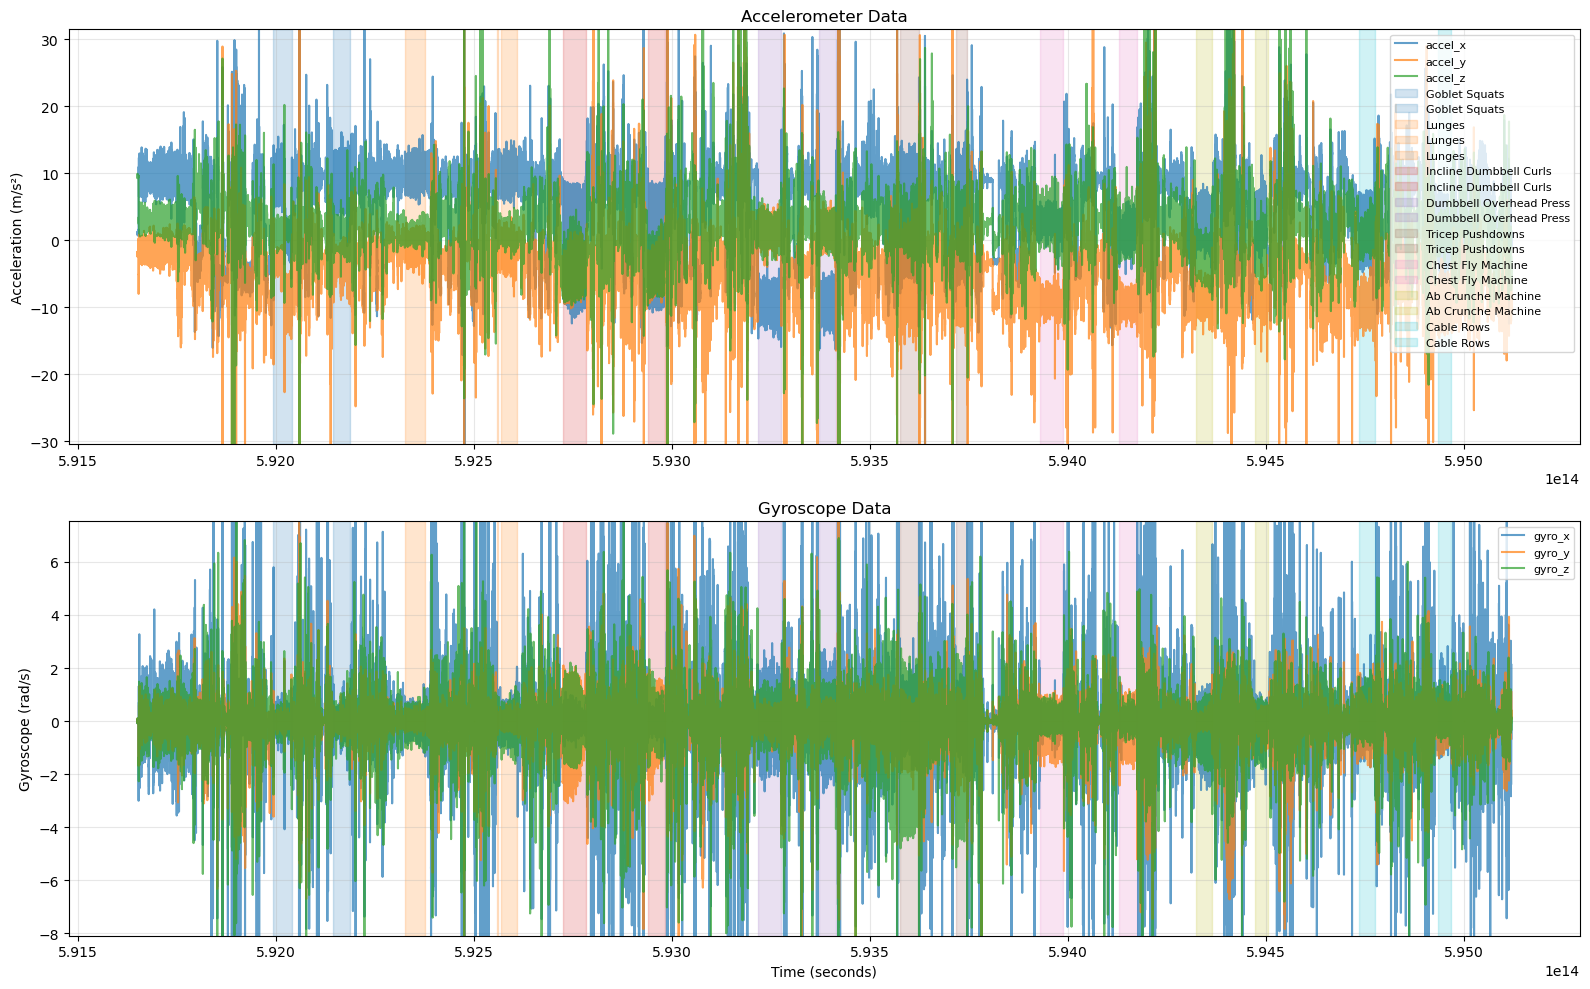

Event synthetic times (ms):
Goblet Squats: 591990866543695ms - 592039555543695ms
Goblet Squats: 592142848543695ms - 592186642543695ms
Lunges: 592324590543695ms - 592376435543695ms
Lunges: 592558730543695ms - 592558856543695ms
Lunges: 592567679543695ms - 592607444543695ms
Incline Dumbbell Curls: 592723345543695ms - 592782793543695ms
Incline Dumbbell Curls: 592937631543695ms - 592982819543695ms
Dumbbell Overhead Press: 593217328543695ms - 593275845543695ms
Dumbbell Overhead Press: 593370810543695ms - 593414503543695ms
Tricep Pushdowns: 593575887543695ms - 593621968543695ms
Tricep Pushdowns: 593716592543695ms - 593745053543695ms
Chest Fly Machine: 593928447543695ms - 593987968543695ms
Chest Fly Machine: 594128979543695ms - 594174670543695ms
Ab Crunche Machine: 594321338543695ms - 594362733543695ms
Ab Crunche Machine: 594471217543695ms - 594503485543695ms
Cable Rows: 594733246543695ms - 594774141543695ms
Cable Rows: 594932762543695ms - 594966430543695ms


In [34]:
plot_recording(combined_with_annotations, events_synthetic)

In [35]:
combined_with_annotations.iloc[38101]

timestamp    592412439319707
accel_x            -2.889801
accel_y            -6.746861
accel_z             6.083666
gyro_x                1.1863
gyro_y               0.40928
gyro_z              0.163712
event                   None
Name: 38101, dtype: object

## Add predictions column to combined dataframe

In [36]:
# combined_with_annotations["timestamp"] matches in classification["accel_timestamps"]
def check_combined_classification_alignment(combined, classification):
    combined_timestamps = set(combined['timestamp'])
    for idx, row in classification.iterrows():
        accel_timestamps = set(int(ts) for ts in row['accel_timestamps'].split(';'))
        accel_in_combined = accel_timestamps.issubset(combined_timestamps)
        if not accel_in_combined:
            print(f"Row {idx}: Some accel timestamps not in combined")
    print("Alignment check completed.")

In [37]:
check_combined_classification_alignment(combined_with_annotations, classification)

Row 0: Some accel timestamps not in combined
Row 1: Some accel timestamps not in combined
Alignment check completed.


In [38]:
combined_with_predictions = add_predictions_to_combined(combined_with_annotations, classification)
combined_with_predictions.head(10)

,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,event,prediction_float,prediction_binary
0,591649351543695,0.883460,-1.783680,9.488221,-0.019548,0.084299,-0.072082,None,0.224435,0.0
1,591649371652618,0.995988,-1.898602,9.380483,-0.064752,0.075747,-0.080634,None,0.224435,0.0
2,591649391724580,1.010353,-2.114080,9.232041,-0.029322,0.059865,-0.067195,None,0.224435,0.0
3,591649413884080,0.998382,-1.975216,9.502586,0.048869,0.050091,-0.059865,None,0.011682,0.0
4,591649431993426,1.024718,-1.764527,9.366117,0.043982,0.036652,-0.076969,None,0.011682,0.0
5,591649452091772,1.106121,-1.956063,9.380483,0.018326,0.017104,-0.063530,None,0.011682,0.0
6,591649472179925,1.103727,-1.960851,9.378088,-0.002443,-0.013439,-0.062308,None,0.011682,0.0
7,591649492266272,1.094150,-2.066196,9.351752,-0.026878,-0.028100,-0.061087,None,0.011682,0.0
8,591649512346618,1.098939,-2.229002,9.528923,-0.015882,-0.045204,-0.063530,None,0.011682,0.0
9,591649532436156,1.079785,-2.286462,9.610326,-0.009774,-0.065973,-0.047647,None,0.011682,0.0


In [39]:
def plot_recording_with_predictions(data):
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

    time = data["timestamp"]

    # --- Plot 1: Accelerometer data ---
    ax1.plot(time, data['accel_x'], label='accel_x', alpha=0.7)
    ax1.plot(time, data['accel_y'], label='accel_y', alpha=0.7)
    ax1.plot(time, data['accel_z'], label='accel_z', alpha=0.7)

    accel_data = data[['accel_x', 'accel_y', 'accel_z']].values
    accel_min, accel_max = np.percentile(accel_data, [1, 99])
    accel_range = accel_max - accel_min
    ax1.set_ylim([accel_min - 0.5*accel_range, accel_max + 0.5*accel_range])
    ax1.set_ylabel('Acceleration (m/s²)')
    ax1.set_title('Accelerometer Data')
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.3)

    # --- Plot 2: Gyroscope data ---
    ax2.plot(time, data['gyro_x'], label='gyro_x', alpha=0.7)
    ax2.plot(time, data['gyro_y'], label='gyro_y', alpha=0.7)
    ax2.plot(time, data['gyro_z'], label='gyro_z', alpha=0.7)

    gyro_data = data[['gyro_x', 'gyro_y', 'gyro_z']].values
    gyro_min, gyro_max = np.percentile(gyro_data, [1, 99])
    gyro_range = gyro_max - gyro_min
    ax2.set_ylim([gyro_min - 0.5*gyro_range, gyro_max + 0.5*gyro_range])
    ax2.set_ylabel('Gyroscope (rad/s)')
    ax2.set_title('Gyroscope Data')
    ax2.legend(loc='upper right', fontsize=8)
    ax2.grid(True, alpha=0.3)

    # --- Plot 3: Predictions ---
    ax3.plot(time, data['prediction_float'], label='Predictions', color='black', linewidth=1.5, alpha=0.7)
    ax3.plot(time, data['prediction_binary'], label='Exercise/ noexercise', color='red', linewidth=1.5, alpha=0.4)
    ax3.axhline(y=0.5, color='red', linestyle='--', label='threshold (0.5)')
    ax3.set_ylabel('Probability')
    ax3.set_xlabel('Time (ms)')
    ax3.set_ylim([-0.1, 1.1])
    ax3.grid(True, alpha=0.3)

    # --- Overlay Event Durations ---
    # 1. Identify where events start/end
    event_col = data['event'].fillna('None')
    event_changes = event_col != event_col.shift()
    data['event_group'] = event_changes.cumsum()

    # 2. Map unique events to colors (FIXED DEPRECATION)
    unique_events = [e for e in event_col.unique() if e != 'None']
    
    # Use the new recommended way to get the colormap
    cmap = plt.get_cmap('tab10') 
    event_to_color = {name: cmap(i % 10) for i, name in enumerate(unique_events)}

    # 3. Iterate through each contiguous block
    for _, group in data.groupby('event_group'):
        evt_name = group['event'].iloc[0]
        
        if pd.isna(evt_name) or evt_name == 'None':
            continue
            
        t_start = group['timestamp'].iloc[0]
        t_end = group['timestamp'].iloc[-1]
        color = event_to_color[evt_name]

        for ax in [ax1, ax2, ax3]:
            ax.axvspan(t_start, t_end, color=color, alpha=0.15)
            
            if ax == ax1:
                ax1.text((t_start + t_end) / 2, ax1.get_ylim()[1], evt_name, 
                        ha='center', va='bottom', color=color, fontweight='bold', fontsize=9)

    plt.tight_layout()
    plt.show()

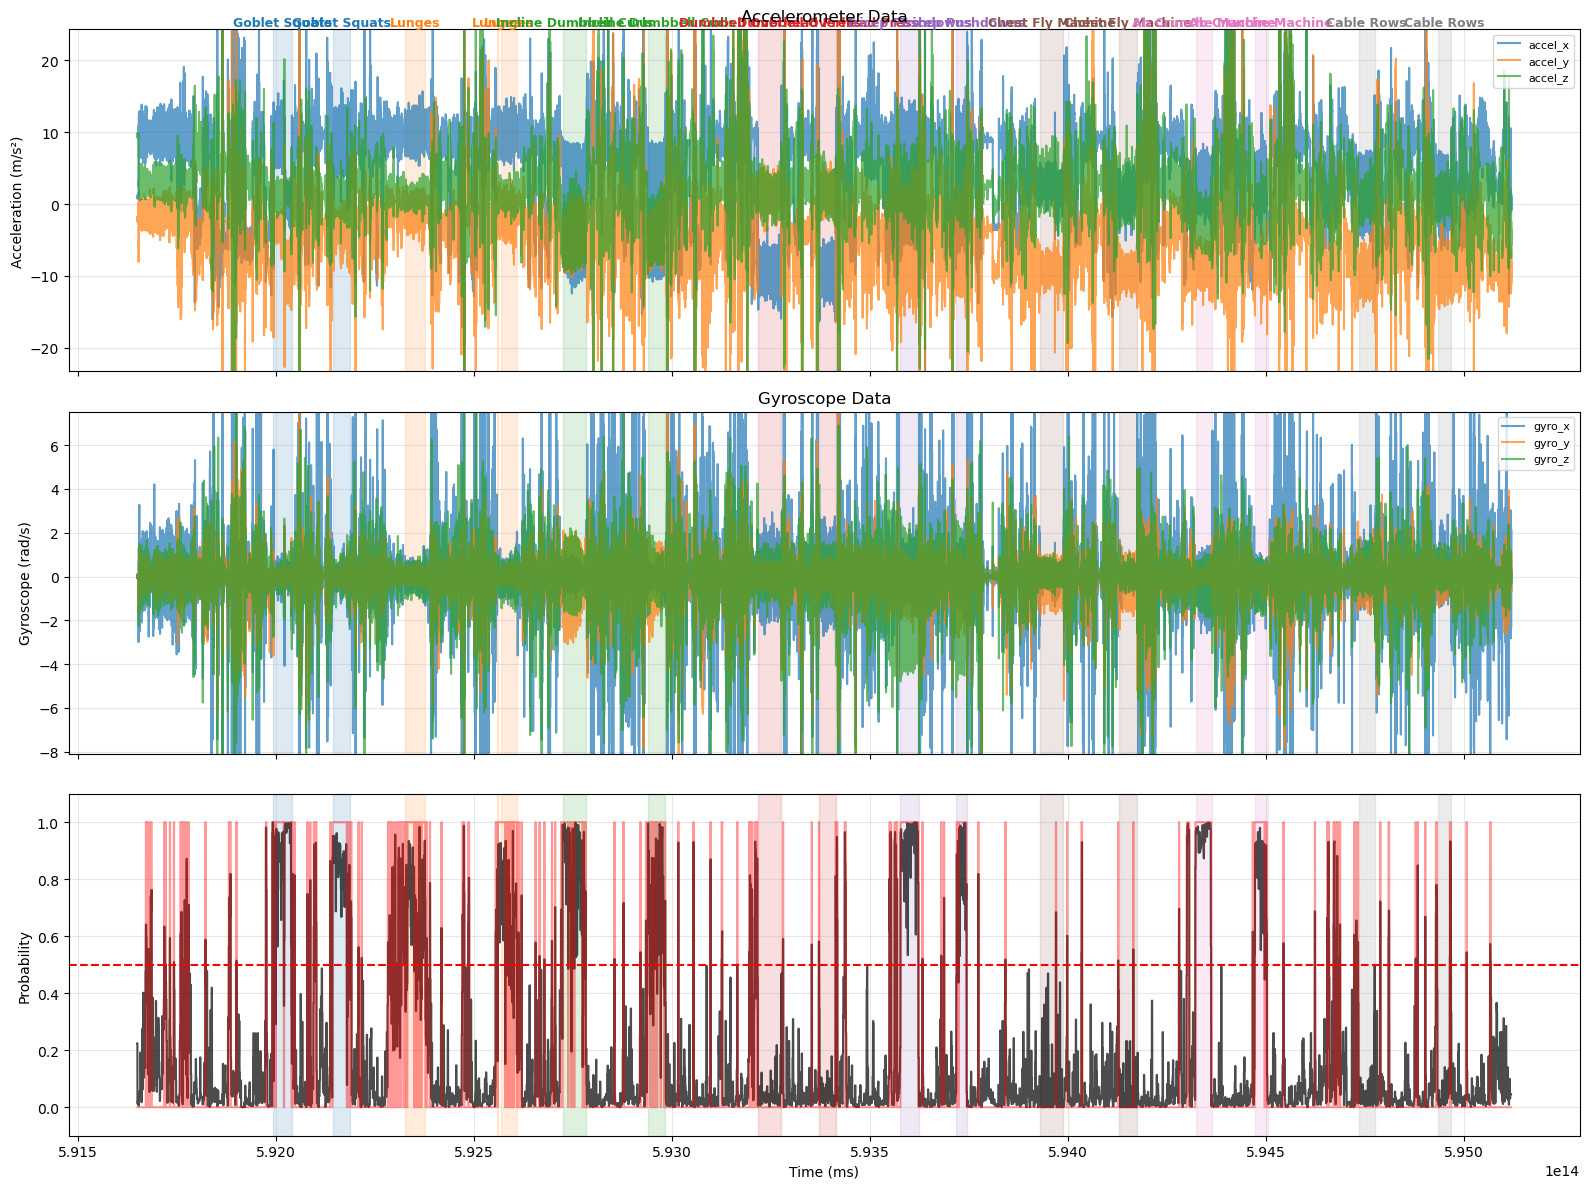

In [40]:
plot_recording_with_predictions(combined_with_predictions)

# smooth out predictions binary

In [41]:
df = combined_with_predictions

In [42]:
df.rolling

<bound method NDFrame.rolling of               timestamp   accel_x    accel_y   accel_z    gyro_x    gyro_y  \
0       591649351543695  0.883460  -1.783680  9.488221 -0.019548  0.084299   
1       591649371652618  0.995988  -1.898602  9.380483 -0.064752  0.075747   
2       591649391724580  1.010353  -2.114080  9.232041 -0.029322  0.059865   
3       591649413884080  0.998382  -1.975216  9.502586  0.048869  0.050091   
4       591649431993426  1.024718  -1.764527  9.366117  0.043982  0.036652   
...                 ...       ...        ...       ...       ...       ...   
173101  595118706549386 -0.557849 -10.146626 -3.311181  0.210138  0.166155   
173102  595118726587540  0.835576  -8.257602 -3.076549  0.125838  0.089186   
173103  595118746625309  1.398214  -9.270349 -3.653552 -0.384845  0.109956   
173104  595118766662270 -0.940921 -10.019734 -4.903325 -0.348193  0.400728   
173105  595118786708270 -0.095768  -9.514558 -3.643975 -0.659735  0.249233   

          gyro_z event  predic

In [43]:
df = combined_with_predictions
for idx, row in df.iterrows():
    if idx < 3:
        continue

    previous3 = df.iloc[idx-3:idx-1]["prediction_binary"]

    print(previous3.values)

    if idx > 4:
        break

[0. 0.]
[0. 0.]
[0. 0.]
